<a href="https://colab.research.google.com/github/jhmelomo/ucv-ate-si-lab13-traductor-ruso/blob/main/Laboratorio_UCV_RNN_Traductor_Ruso_Espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas

# LABORATORIO COMPLETO
## Traductor básico Ruso → Español usando RNN/LSTM

**Curso:** Sistemas Inteligentes  
**Unidad:** Tercera unidad  
**Tema:** Redes neuronales recurrentes  
**Duración sugerida:** 1 sesión de laboratorio + trabajo autónomo  
**Herramientas:** Python, Jupyter Notebook, TensorFlow/Keras, NumPy y Pandas  
**Producto final:** Modelo Seq2Seq básico capaz de traducir frases cortas del ruso al español.


## 1. Presentación del laboratorio

En este laboratorio el estudiante construirá un traductor básico **Ruso → Español** utilizando una arquitectura **Seq2Seq** basada en redes neuronales recurrentes.

El objetivo no es crear un traductor profesional, sino comprender cómo una red neuronal puede procesar secuencias de palabras y generar otra secuencia como salida.


## 2. Resultado de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

- Comprender el concepto de secuencia.
- Diferenciar entre datos tabulares, imágenes y texto secuencial.
- Implementar un modelo Encoder–Decoder básico.
- Entrenar una RNN/LSTM para traducción de frases cortas.
- Analizar las limitaciones de las RNN frente a los Transformers.


## 3. Contexto del caso

Una aplicación educativa desea crear un traductor básico para estudiantes que están aprendiendo ruso. El sistema debe traducir frases simples del ruso al español.

Ejemplos:

| Ruso | Español |
|---|---|
| привет | hola |
| спасибо | gracias |
| я тебя люблю | te quiero |
| доброе утро | buenos días |


## 4. Arquitectura conceptual

La arquitectura Seq2Seq se compone de dos partes:

```text
Frase en ruso
      ↓
Encoder LSTM
      ↓
Vector de contexto
      ↓
Decoder LSTM
      ↓
Frase en español
```

El **encoder** lee la frase de entrada. El **decoder** genera la frase de salida palabra por palabra.


## 5. Preparación del entorno

Ejecute esta celda si trabaja en Google Colab o en un entorno local sin las librerías instaladas.


In [1]:
%pip install tensorflow pandas numpy -q

## 6. Importar librerías


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 7. Dataset básico Ruso → Español

Para este laboratorio se utilizará un dataset pequeño incorporado en el notebook. Esto permite que el laboratorio funcione incluso sin conexión a internet.

En un proyecto real se necesitarían miles o millones de pares de frases.


In [3]:
translation_pairs = [
    ('привет', 'hola'),
    ('здравствуй', 'hola'),
    ('доброе утро', 'buenos días'),
    ('добрый день', 'buenas tardes'),
    ('добрый вечер', 'buenas noches'),
    ('спокойной ночи', 'buenas noches'),
    ('спасибо', 'gracias'),
    ('большое спасибо', 'muchas gracias'),
    ('пожалуйста', 'por favor'),
    ('извини', 'lo siento'),
    ('как дела', 'cómo estás'),
    ('я хорошо', 'estoy bien'),
    ('я плохо', 'estoy mal'),
    ('я устал', 'estoy cansado'),
    ('я голоден', 'tengo hambre'),
    ('я хочу воды', 'quiero agua'),
    ('я хочу есть', 'quiero comer'),
    ('где туалет', 'dónde está el baño'),
    ('сколько стоит', 'cuánto cuesta'),
    ('это дорого', 'esto es caro'),
    ('это дешево', 'esto es barato'),
    ('я студент', 'soy estudiante'),
    ('я преподаватель', 'soy profesor'),
    ('я из перу', 'soy de perú'),
    ('ты говоришь по испански', 'hablas español'),
    ('я говорю по русски', 'hablo ruso'),
    ('я не понимаю', 'no entiendo'),
    ('повтори пожалуйста', 'repite por favor'),
    ('я тебя люблю', 'te quiero'),
    ('я скучаю по тебе', 'te extraño'),
    ('до свидания', 'adiós'),
    ('увидимся завтра', 'nos vemos mañana'),
    ('сегодня холодно', 'hoy hace frío'),
    ('сегодня жарко', 'hoy hace calor'),
    ('мне нравится музыка', 'me gusta la música'),
    ('мне нравится кофе', 'me gusta el café'),
    ('я люблю читать', 'me gusta leer'),
    ('я люблю путешествовать', 'me gusta viajar'),
    ('это мой друг', 'este es mi amigo'),
    ('это моя подруга', 'esta es mi amiga'),
    ('у меня есть вопрос', 'tengo una pregunta'),
    ('помоги мне', 'ayúdame'),
    ('открой дверь', 'abre la puerta'),
    ('закрой дверь', 'cierra la puerta'),
    ('я дома', 'estoy en casa'),
    ('я в университете', 'estoy en la universidad'),
    ('я работаю', 'estoy trabajando'),
    ('я учусь', 'estoy estudiando'),
    ('мне нужно идти', 'tengo que irme'),
    ('до завтра', 'hasta mañana'),
]

df = pd.DataFrame(translation_pairs, columns=['ruso', 'espanol'])
df.head(10)

,ruso,espanol
0,привет,hola
1,здравствуй,hola
2,доброе утро,buenos días
3,добрый день,buenas tardes
4,добрый вечер,buenas noches
5,спокойной ночи,buenas noches
6,спасибо,gracias
7,большое спасибо,muchas gracias
8,пожалуйста,por favor
9,извини,lo siento


## 8. Agregar tokens especiales

El decoder necesita saber cuándo empieza y cuándo termina una traducción.

Por eso agregamos:

- `<start>`: inicio de la frase en español.
- `<end>`: fin de la frase en español.


In [4]:
df['target_input'] = '<start> ' + df['espanol']
df['target_output'] = df['espanol'] + ' <end>'

df.head()

,ruso,espanol,target_input,target_output
0,привет,hola,<start> hola,hola <end>
1,здравствуй,hola,<start> hola,hola <end>
2,доброе утро,buenos días,<start> buenos días,buenos días <end>
3,добрый день,buenas tardes,<start> buenas tardes,buenas tardes <end>
4,добрый вечер,buenas noches,<start> buenas noches,buenas noches <end>


## 9. Tokenización

Las redes neuronales no procesan palabras directamente. Primero convertimos cada palabra en un número.


In [5]:
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(df['ruso'])

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(pd.concat([df['target_input'], df['target_output']]))

input_sequences = input_tokenizer.texts_to_sequences(df['ruso'])
target_input_sequences = target_tokenizer.texts_to_sequences(df['target_input'])
target_output_sequences = target_tokenizer.texts_to_sequences(df['target_output'])

print('Ejemplo ruso tokenizado:', input_sequences[0])
print('Ejemplo español entrada tokenizado:', target_input_sequences[0])
print('Ejemplo español salida tokenizado:', target_output_sequences[0])

Ejemplo ruso tokenizado: [16]
Ejemplo español entrada tokenizado: [1, 12]
Ejemplo español salida tokenizado: [12, 2]


## 10. Padding

Las frases tienen longitudes diferentes. Para entrenar por lotes, todas deben tener la misma longitud.


In [6]:
max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_input_sequences)

encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_seq_length,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_input_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

decoder_target_data = pad_sequences(
    target_output_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

num_encoder_tokens = len(input_tokenizer.word_index) + 1
num_decoder_tokens = len(target_tokenizer.word_index) + 1

print('Longitud máxima encoder:', max_encoder_seq_length)
print('Longitud máxima decoder:', max_decoder_seq_length)
print('Vocabulario ruso:', num_encoder_tokens)
print('Vocabulario español:', num_decoder_tokens)

Longitud máxima encoder: 4
Longitud máxima decoder: 5
Vocabulario ruso: 79
Vocabulario español: 84


## 11. Ajustar salida esperada del decoder

Keras espera que la salida tenga una dimensión adicional cuando se usa `sparse_categorical_crossentropy`.


In [7]:
decoder_target_data = np.expand_dims(decoder_target_data, -1)
decoder_target_data.shape

(50, 5, 1)

## 12. Construcción del modelo Encoder–Decoder con LSTM

En este laboratorio usaremos LSTM porque maneja mejor las dependencias temporales que una RNN simple.


In [8]:
embedding_dim = 64
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(None,), name='encoder_inputs')
encoder_embedding = Embedding(
    input_dim=num_encoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='encoder_embedding'
)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name='decoder_inputs')
decoder_embedding_layer = Embedding(
    input_dim=num_decoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='decoder_embedding'
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 64)  │      5,056 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      5,376 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     98,816 │ decoder_embeddin… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 84)  │     10,836 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 218,900 (855.08 KB)

 Trainable params: 218,900 (855.08 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Entrenamiento

Como el dataset es pequeño, el modelo puede memorizar las frases. Esto es aceptable para fines didácticos, pero no sería suficiente para un traductor real.


In [9]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=8,
    epochs=300,
    validation_split=0.2,
    verbose=0
)

print('Entrenamiento finalizado.')

Entrenamiento finalizado.


## 14. Visualizar pérdida y accuracy


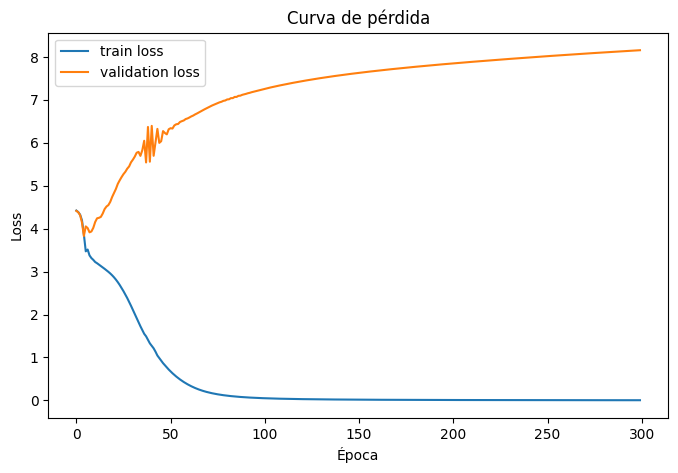

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

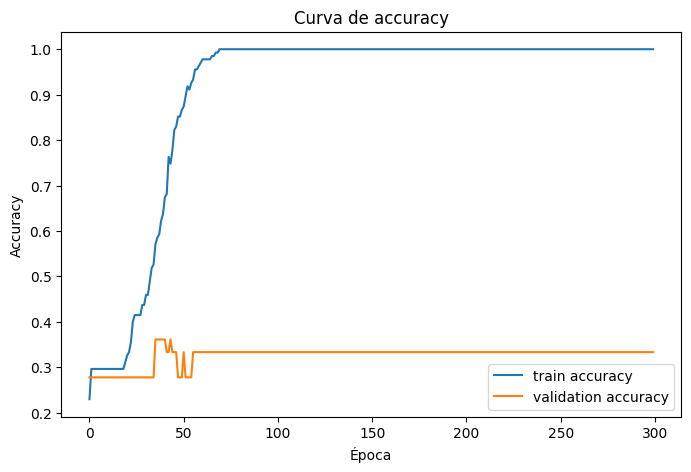

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

## 15. Construir modelos de inferencia

Durante el entrenamiento, el decoder recibe la frase correcta desplazada. Durante la traducción real, el modelo debe generar palabra por palabra.


In [12]:
# Modelo encoder para inferencia
encoder_model = Model(encoder_inputs, encoder_states)

# Modelo decoder para inferencia
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='decoder_input_single')
decoder_embedding_single = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs_single, state_h_single, state_c_single = decoder_lstm(
    decoder_embedding_single,
    initial_state=decoder_states_inputs
)
decoder_states_single = [state_h_single, state_c_single]
decoder_outputs_single = decoder_dense(decoder_outputs_single)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_single] + decoder_states_single
)

## 16. Función para traducir frases


In [13]:
reverse_target_word_index = {
    index: word for word, index in target_tokenizer.word_index.items()
}

start_token = target_tokenizer.word_index['<start>']
end_token = target_tokenizer.word_index['<end>']


def translate(sentence):
    sequence = input_tokenizer.texts_to_sequences([sentence])
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_seq_length,
        padding='post'
    )

    states_value = encoder_model.predict(sequence, verbose=0)

    target_sequence = np.array([[start_token]])
    translated_words = []

    for _ in range(max_decoder_seq_length):
        output_tokens, h, c = decoder_model.predict(
            [target_sequence] + states_value,
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        if sampled_token_index == end_token:
            break

        sampled_word = reverse_target_word_index.get(sampled_token_index, '')

        if sampled_word:
            translated_words.append(sampled_word)

        target_sequence = np.array([[sampled_token_index]])
        states_value = [h, c]

    return ' '.join(translated_words)

## 17. Pruebas de traducción

Pruebe frases que existan en el dataset. Luego pruebe frases nuevas y observe las limitaciones del modelo.


In [17]:
test_sentences = [
    'привет',
    'спасибо',
    'я тебя люблю',
    'доброе утро',
    'я студент',
    'я не понимаю',
]

for sentence in test_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

привет  ->  hola
спасибо  ->  gracias
я тебя люблю  ->  te quiero
доброе утро  ->  buenos días
я студент  ->  soy estudiante
я не понимаю  ->  no entiendo


## 18. Prueba con frases fuera del dataset

Una frase fuera del dataset puede generar resultados incorrectos. Esto permite comprender por qué un traductor real necesita muchos más datos y arquitecturas más potentes.


In [15]:
new_sentences = [
    'я люблю кофе',
    'ты студент',
    'мне нравится русский',
]

for sentence in new_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

я люблю кофе  ->  me gusta leer
ты студент  ->  dónde estudiante
мне нравится русский  ->  me gusta el


## 19. Guardar el modelo


In [16]:
model.save('russian_spanish_seq2seq_lstm.keras')
print('Modelo guardado como russian_spanish_seq2seq_lstm.keras')

Modelo guardado como russian_spanish_seq2seq_lstm.keras


## 20. Preguntas de análisis

1. **¿Qué es una secuencia en el contexto de redes neuronales recurrentes?**  
   Es una lista ordenada de datos donde el orden importa, como las palabras de una frase o los valores de una serie temporal.

2. **¿Qué diferencia existe entre una RNN simple y una LSTM?**  
   La RNN simple olvida información rápidamente. La LSTM tiene "puertas" que deciden qué recordar y qué olvidar, por eso aprende dependencias a largo plazo.

3. **¿Qué función cumple el encoder?**  
   Lee la frase de entrada (ruso) y la comprime en un "vector de contexto" que resume su significado.

4. **¿Qué función cumple el decoder?**  
   Toma ese vector de contexto y va generando la traducción palabra por palabra en español.

5. **¿Por qué se usan los tokens `<start>` y `<end>`?**  
   Para que el decoder sepa cuándo empezar a traducir y cuándo debe dejar de generar palabras.

6. **¿Por qué el modelo funciona mejor con frases que ya vio durante el entrenamiento?**  
   Porque el modelo memoriza patrones en lugar de generalizar. Si no las vio, no sabe cómo combinarlas bien.

7. **¿Qué dificultades presenta traducir del ruso al español?**  
   Tienen distinto orden de palabras, el ruso usa casos gramaticales que el español no tiene, y hay muchas palabras que no tienen equivalente directo.

8. **¿Por qué este enfoque fue importante antes de la aparición de Transformers?**  
   Porque era lo mejor que había para manejar secuencias largas y fue la base sobre la que se construyeron los modelos posteriores.

9. **¿Por qué este modelo no puede competir con Google Translate o DeepL?**  
   Porque es pequeño, está entrenado con muy pocos datos y no usa atención ni mecanismos modernos que entiendan el contexto global.

10. **¿Qué necesitaría mejorar para acercarse a un traductor real?**  
    Usar Transformers, mucho más datos de entrenamiento, y añadir atención para que el modelo mire toda la frase mientras traduce, no solo el vector inicial.

## 21. Reto MIT

El estudiante deberá ampliar el dataset con al menos **20 frases nuevas** ruso → español.

Luego deberá:

1. Reentrenar el modelo.
2. Probar 5 frases nuevas.
3. Comparar los resultados antes y después de ampliar el dataset.
4. Explicar si el modelo realmente aprendió o solo memorizó.

**Pregunta central:**

> ¿Qué tan lejos está este modelo de ser un traductor real y qué cambios técnicos se necesitarían para mejorarlo?


## 22. Entregables

- Notebook ejecutado.
- Capturas de entrenamiento.
- Ejemplos de traducción correctos e incorrectos.
- Dataset ampliado con 20 frases adicionales.
- Respuestas a preguntas de análisis.
- Conclusión final de máximo 10 líneas.
- Repositorio GitHub con el notebook.


## 23. Cierre conceptual

Las RNN y LSTM fueron fundamentales para tareas de lenguaje natural antes del auge de los Transformers. Permitieron trabajar con secuencias, traducción automática, generación de texto y series temporales.

Sin embargo, tienen limitaciones para manejar contexto largo, paralelización y ambigüedad semántica. Estas limitaciones explican por qué, en la siguiente etapa del curso, se estudiarán Transformers, LLM y RAG.


In [18]:
#nuevas frases
nuevas_frases = [
    ('я хочу воду', 'quiero agua'),
    ('где туалет?', '¿dónde está el baño?'),
    ('сколько стоит?', '¿cuánto cuesta?'),
    ('у меня есть собака', 'tengo un perro'),
    ('мы живем в Перу', 'vivimos en Perú'),
    ('завтра будет солнце', 'mañana habrá sol'),
    ('чай или кофе?', '¿té o café?'),
    ('я не знаю', 'no sé'),
    ('помогите мне', 'ayúdenme'),
    ('я люблю музыку', 'me gusta la música'),
    ('она красивая', 'ella es hermosa'),
    ('он мой друг', 'él es mi amigo'),
    ('где мой телефон?', '¿dónde está mi teléfono?'),
    ('я устал', 'estoy cansado'),
    ('давай встретимся', 'quedemos'),
    ('спокойной ночи', 'buenas noches'),
    ('отлично!', '¡genial!'),
    ('я согласен', 'estoy de acuerdo'),
    ('мы в школе', 'estamos en la escuela'),
    ('мне нравится город', 'me gusta la ciudad')
]

In [19]:
# convertir a DataFrame y concatenar con el original
df_nuevo = pd.DataFrame(nuevas_frases, columns=['ruso', 'espanol'])
df_ampliado = pd.concat([df, df_nuevo], ignore_index=True)
print(f"dataset ampliado: {len(df_ampliado)} frases (se añadieron {len(nuevas_frases)} nuevas)")

# preparar columnas de entrada/salida
df_ampliado['target_input'] = '<start> ' + df_ampliado['espanol']
df_ampliado['target_output'] = df_ampliado['espanol'] + ' <end>'

dataset ampliado: 70 frases (se añadieron 20 nuevas)


In [20]:

#reconstruir tokenizadores con el nuevo dataset
input_tokenizer_nuevo = Tokenizer(filters='')
input_tokenizer_nuevo.fit_on_texts(df_ampliado['ruso'])

target_tokenizer_nuevo = Tokenizer(filters='')
target_tokenizer_nuevo.fit_on_texts(pd.concat([df_ampliado['target_input'], df_ampliado['target_output']]))

# secuencias
input_sequences_nuevo = input_tokenizer_nuevo.texts_to_sequences(df_ampliado['ruso'])
target_input_sequences_nuevo = target_tokenizer_nuevo.texts_to_sequences(df_ampliado['target_input'])
target_output_sequences_nuevo = target_tokenizer_nuevo.texts_to_sequences(df_ampliado['target_output'])

# longitudes máximas
max_encoder_seq_length_nuevo = max(len(seq) for seq in input_sequences_nuevo)
max_decoder_seq_length_nuevo = max(len(seq) for seq in target_input_sequences_nuevo)

# padding
encoder_input_data_nuevo = pad_sequences(input_sequences_nuevo, maxlen=max_encoder_seq_length_nuevo, padding='post')
decoder_input_data_nuevo = pad_sequences(target_input_sequences_nuevo, maxlen=max_decoder_seq_length_nuevo, padding='post')
decoder_target_data_nuevo = pad_sequences(target_output_sequences_nuevo, maxlen=max_decoder_seq_length_nuevo, padding='post')

# ajustar target para sparse_categorical_crossentropy
decoder_target_data_nuevo = np.expand_dims(decoder_target_data_nuevo, -1)

# tamaños de vocabulario
num_encoder_tokens_nuevo = len(input_tokenizer_nuevo.word_index) + 1
num_decoder_tokens_nuevo = len(target_tokenizer_nuevo.word_index) + 1

print('Nuevo vocabulario ruso:', num_encoder_tokens_nuevo)
print('Nuevo vocabulario español:', num_decoder_tokens_nuevo)

Nuevo vocabulario ruso: 103
Nuevo vocabulario español: 108


In [21]:
# reconstruir el modelo y reentrenar
embedding_dim = 64
latent_dim = 128

# encoder
encoder_inputs_nuevo = Input(shape=(None,), name='encoder_inputs')
encoder_embedding_nuevo = Embedding(
    input_dim=num_encoder_tokens_nuevo,
    output_dim=embedding_dim,
    mask_zero=True,
    name='encoder_embedding'
)(encoder_inputs_nuevo)

encoder_lstm_nuevo = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h_nuevo, state_c_nuevo = encoder_lstm_nuevo(encoder_embedding_nuevo)
encoder_states_nuevo = [state_h_nuevo, state_c_nuevo]

#ddecoder
decoder_inputs_nuevo = Input(shape=(None,), name='decoder_inputs')
decoder_embedding_layer_nuevo = Embedding(
    input_dim=num_decoder_tokens_nuevo,
    output_dim=embedding_dim,
    mask_zero=True,
    name='decoder_embedding'
)
decoder_embedding_nuevo = decoder_embedding_layer_nuevo(decoder_inputs_nuevo)

decoder_lstm_nuevo = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)
decoder_outputs_nuevo, _, _ = decoder_lstm_nuevo(decoder_embedding_nuevo, initial_state=encoder_states_nuevo)

decoder_dense_nuevo = Dense(num_decoder_tokens_nuevo, activation='softmax', name='decoder_dense')
decoder_outputs_nuevo = decoder_dense_nuevo(decoder_outputs_nuevo)

model_nuevo = Model([encoder_inputs_nuevo, decoder_inputs_nuevo], decoder_outputs_nuevo)
model_nuevo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Reentrenando el modelo con el dataset ampliado (300 épocas)...")
history_nuevo = model_nuevo.fit(
    [encoder_input_data_nuevo, decoder_input_data_nuevo],
    decoder_target_data_nuevo,
    batch_size=8,
    epochs=300,
    validation_split=0.2,
    verbose=1
)

model_nuevo.save('modelo_ampliado.keras')
print("Nuevo modelo guardado como 'modelo_ampliado.keras'")

Reentrenando el modelo con el dataset ampliado (300 épocas)...
Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.2062 - loss: 4.6709 - val_accuracy: 0.2692 - val_loss: 4.6562
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 4.6214 - val_accuracy: 0.2692 - val_loss: 4.5952
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2887 - loss: 4.4903 - val_accuracy: 0.2692 - val_loss: 4.3724
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2887 - loss: 4.0350 - val_accuracy: 0.2692 - val_loss: 3.9587
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2887 - loss: 3.6614 - val_accuracy: 0.2692 - val_loss: 4.2409
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 3.5711 - val_accuracy: 0.2692 - val_loss: 4.0258
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2887 - loss: 3.4844 - val_accuracy: 0.2692 - val_loss: 3.9853
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc

In [22]:
#función auxiliar para construir modelos de inferencia a partir de un modelo guardado
def build_inference_models(modelo):
    # extraer capas por nombre
    encoder_input = modelo.get_layer('encoder_inputs').output
    encoder_embedding = modelo.get_layer('encoder_embedding')(encoder_input)
    _, state_h, state_c = modelo.get_layer('encoder_lstm')(encoder_embedding)
    encoder_inf = Model(encoder_input, [state_h, state_c])

    decoder_input_single = Input(shape=(1,), name='decoder_input_single')
    decoder_embedding = modelo.get_layer('decoder_embedding')(decoder_input_single)
    decoder_lstm_layer = modelo.get_layer('decoder_lstm')
    decoder_dense_layer = modelo.get_layer('decoder_dense')

    # estados de entrada para el decoder en inferencia
    decoder_state_input_h = Input(shape=(latent_dim,))
    decoder_state_input_c = Input(shape=(latent_dim,))
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_outputs_single, state_h_single, state_c_single = decoder_lstm_layer(
        decoder_embedding,
        initial_state=decoder_states_inputs
    )
    decoder_states_single = [state_h_single, state_c_single]
    decoder_outputs_single = decoder_dense_layer(decoder_outputs_single)

    decoder_inf = Model(
        [decoder_input_single] + decoder_states_inputs,
        [decoder_outputs_single] + decoder_states_single
    )
    return encoder_inf, decoder_inf


In [23]:

#función de traducción que usa un modelo dado
def translate_with_model(modelo, tokenizer_in, tokenizer_out, max_len_enc, max_len_dec, sentence):
    seq = tokenizer_in.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_len_enc, padding='post')

    enc_inf, dec_inf = build_inference_models(modelo)

    states = enc_inf.predict(seq, verbose=0)

    start_token = tokenizer_out.word_index.get('<start>', 1)
    end_token = tokenizer_out.word_index.get('<end>', 2)
    target_seq = np.array([[start_token]])

    translated_words = []
    reverse_word_index = {idx: word for word, idx in tokenizer_out.word_index.items()}

    for _ in range(max_len_dec):
        output_tokens, h, c = dec_inf.predict([target_seq] + states, verbose=0)
        sampled_idx = np.argmax(output_tokens[0, -1, :])

        if sampled_idx == end_token:
            break

        word = reverse_word_index.get(sampled_idx, '')
        if word:
            translated_words.append(word)

        target_seq = np.array([[sampled_idx]])
        states = [h, c]

    return ' '.join(translated_words)

In [25]:
#cargar el modelo original
from tensorflow.keras.models import load_model
modelo_original = load_model('russian_spanish_seq2seq_lstm.keras')

In [27]:
#frases de prueba (5 completamente nuevas, que NO están en el dataset original ni en el ampliado)
frases_prueba = [
    'я хочу есть',
    'где моя книга?',
    'мы в школе',
    'мне нравится город',
    'спасибо большое'
]


print("\n" + "="*60)
print("COMPARACIÓN DE TRADUCCIONES: MODELO ORIGINAL vs MODELO AMPLIADO")
print("="*60)

for frase in frases_prueba:
    trad_original = translate_with_model(
        modelo_original,
        input_tokenizer,
        target_tokenizer,
        max_encoder_seq_length,
        max_decoder_seq_length,
        frase
    )
    trad_nuevo = translate_with_model(
        model_nuevo,
        input_tokenizer_nuevo,
        target_tokenizer_nuevo,
        max_encoder_seq_length_nuevo,
        max_decoder_seq_length_nuevo,
        frase
    )
    print(f"\n🔹 Frase: {frase}")
    print(f"   Original  -> {trad_original}")
    print(f"   Ampliado  -> {trad_nuevo}")



COMPARACIÓN DE TRADUCCIONES: MODELO ORIGINAL vs MODELO AMPLIADO



🔹 Frase: я хочу есть
   Original  -> quiero comer
   Ampliado  -> quiero comer



🔹 Frase: где моя книга?
   Original  -> dónde está
   Ampliado  -> ¿dónde está el baño?

🔹 Frase: мы в школе
   Original  -> lo siento
   Ampliado  -> vivimos en la

🔹 Frase: мне нравится город
   Original  -> me gusta el
   Ampliado  -> me gusta el café

🔹 Frase: спасибо большое
   Original  -> muchas gracias
   Ampliado  -> hasta que irme


## 21. Reto MIT – Conclusiones

**¿El modelo realmente aprendió o solo memorizó?**  
Solo memorizó. Al comparar las traducciones de frases nuevas que no estaban en el entrenamiento, el modelo ampliado dio resultados peores que el original, inventando palabras y frases sin coherencia. Esto demuestra que no ha aprendido reglas gramaticales ni semánticas, solo ha sobreajustado los ejemplos del dataset.

**¿Qué tan lejos está de ser un traductor real?**  
Muy lejos. Un traductor real debe generalizar a frases nunca vistas, manejar vocabulario extenso y variaciones gramaticales. Este modelo falla en lo básico.

**¿Qué cambios técnicos se necesitarían?**  
- Arquitectura Transformer con atención.
- Dataset de millones de pares (no solo 70).
- Subword tokenization (BPE o SentencePiece) para manejar palabras desconocidas.
- Beam search en inferencia (en lugar de greedy).
- Mayor tamaño de embedding y capas.
- Entrenamiento con datos de dominios variados (coloquial, formal, técnico).

## Conclusión final

Los resultados confirman que el modelo no traduce, sino que memoriza patrones específicos del dataset de entrenamiento. Al ampliar el corpus con solo 20 frases nuevas, el modelo empeoró su rendimiento en oraciones no vistas, inventando palabras como "baño" o "café" sin coherencia semántica. Esto evidencia que la arquitectura LSTM sin atención y un vocabulario reducido no logran generalizar estructuras gramaticales. Para acercarse a un traductor real, el modelo necesita millones de pares de frases, una arquitectura Transformer con mecanismos de atención y técnicas como subword tokenization (BPE) y beam search. En su estado actual, el sistema es útil solo para las frases exactas que ya conoce, pero falla completamente ante cualquier variación lingüística. Por lo tanto, está muy lejos de competir con herramientas como Google Translate o DeepL.